# Principles of Data Science | Homework Assignment 1 (HA1) :  Comparing COVID Fatalities

In this assignment, you will compare COVID fatalities in Portugal and Colombia. The results may be counterintuitive and surprising! We will use data of COVID cases from both countries on May 28, 2020.

First we load the necessary python packages

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

The Portugal and Colombia data are contained in separate files. 

## Portuguese COVID fatality rate
Let's start by loading the Portuguese data which is stored in the file called `portugal_2020-05-28.csv`.

In [12]:
df_PT = pd.read_csv("portugal_2020-05-28.csv")
df_PT.head()

,age,sex,fatality
0,60-69,Female,0
1,60-69,Male,0
2,80+,Male,0
3,60-69,Female,0
4,50-59,Female,0


**Exercise 1. (*1pt*)** Calculate the overall fatality rate for Portugal. That is, calculate $$P(\text{fatality} = 1 | \text{country}=\text{Portugal}).$$ Store your answer in the variable `fatal_PT` as you will need to use this value in the final exercise.

In [13]:
## YOUR CODE HERE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
df_PT = pd.read_csv("portugal_2020-05-28.csv")

ma = (df_PT.loc[:, "fatality"] == 1)
mb = df_PT.loc[:,"fatality"] == 0
mc = ma + mb

fatal_PT = ( ma.sum()/mc.sum())
fatal_PT

0.04332826940119002

**Exercise 2. (*1pt*)** Calculate the fatality rates for each age group in Portugal. That is, calculate the conditional probabilities for each age group:
$$P(\text{fatality} = 1 | \text{age}\in[a,b], \text{country}=\text{Portugal}).$$
Save the results in a `pd.Series` called `fatality_rates_PT`.

In [14]:
## YOUR CODE HERE
fa0 = (df_PT[df_PT["age"] == '0-9'].loc[:,"fatality"] == 1).sum()
fa01 = (df_PT.loc[:,"age"] == '0-9').sum()
fa1 = (df_PT[df_PT["age"] == '10-19'].loc[:,"fatality"] == 1).sum()
fa11 = (df_PT.loc[:,"age"] == '10-19').sum()
fa2 = (df_PT[df_PT["age"] == '20-29'].loc[:,"fatality"] == 1).sum()
fa21 = (df_PT.loc[:,"age"] == '20-29').sum()
fa3 = (df_PT[df_PT["age"] == '30-39'].loc[:,"fatality"] == 1).sum()
fa31 = (df_PT.loc[:,"age"] == '30-39').sum()
fa4 = (df_PT[df_PT["age"] == '40-49'].loc[:,"fatality"] == 1).sum()
fa41 = (df_PT.loc[:,"age"] == '40-49').sum()
fa5 = (df_PT[df_PT["age"] == '50-59'].loc[:,"fatality"] == 1).sum()
fa51 = (df_PT.loc[:,"age"] == '50-59').sum()
fa6 = (df_PT[df_PT["age"] == '60-69'].loc[:,"fatality"] == 1).sum()
fa61 = (df_PT.loc[:,"age"] == '60-69').sum()
fa7 = (df_PT[df_PT["age"] == '70-79'].loc[:,"fatality"] == 1).sum()
fa71 = (df_PT.loc[:,"age"] == '70-79').sum()
fa8 = (df_PT[df_PT["age"] == '80+'].loc[:,"fatality"] == 1).sum()
fa81 = (df_PT.loc[:,"age"] == '80+').sum()

fr0 = fa0/fa01
fr1 = fa1/fa11
fr2 = fa2/fa21
fr3 = fa3/fa31
fr4 = fa4/fa41
fr5 = fa5/fa51
fr6 = fa6/fa61
fr7 = fa7/fa71
fr8 = fa8/fa81

fr = { 'fatality 0-9' : fr0, 'fatality 10-19' : fr1,'fatality 20-29' : fr2,'fatality 30-39' : fr3,
       'fatality 40-49' : fr4, 'fatality 50-59' : fr5, 'fatality 60-69' : fr6, 'fatality 70-79' : fr7,
       'fatality 80+' : fr8}
fatality_rates_PT = pd.Series(data = fr, index = ['fatality 0-9', 'fatality 10-19', 'fatality 20-29',
                                                  'fatality 30-39', 'fatality 40-49', 'fatality 50-59',
                                                  'fatality 60-69', 'fatality 70-79', 'fatality 80+'])
fatality_rates_PT

fatality 0-9      0.000000
fatality 10-19    0.000000
fatality 20-29    0.000243
fatality 30-39    0.000211
fatality 40-49    0.002822
fatality 50-59    0.007995
fatality 60-69    0.035017
fatality 70-79    0.106031
fatality 80+      0.205180
dtype: float64

## Colombian fatality rate

Next we load the Colombian data from the file `colombia_2020-05-28.csv`. 

In [15]:
df_CO = pd.read_csv("colombia_2020-05-28.csv")
df_CO.head()

,Departamento,Edad,Sexo,Tipo,Ubicación,Estado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha recuperado
0,Bogotá D.C.,19,F,Importado,Recuperado,Leve,2020-02-27,- -,2020-03-06,2020-03-13
1,Valle del Cauca,34,M,Importado,Recuperado,Leve,2020-03-04,- -,2020-03-09,2020-03-19
2,Antioquia,50,F,Importado,Recuperado,Leve,2020-02-29,- -,2020-03-09,2020-03-15
3,Antioquia,55,M,Relacionado,Recuperado,Leve,2020-03-06,- -,2020-03-11,2020-03-26
4,Antioquia,25,M,Relacionado,Recuperado,Leve,2020-03-08,- -,2020-03-11,2020-03-23


Notice that the Colombia data is more raw than the Portugal data. We need to clean the data to make it look like the Portugal data. For instance, it does not contain a boolean "fatality" column and the ages ("Edad") are indicated as exact ages rather than binned values as we can see for the Portuguese data.

As a first step, we will create a column called fatality which indicates whether a patient died or not by transforming the "Estado" (state) column into a fatality column. If a patient died, then their state is marked as "Fallecido" (deceased). There are other "Estados" (states), such as "Leve" (mild) and "Asintomático" (asymptomatic), but these are not relevant for our fatality column.

**Exercise 3. (*1pt*)** Add a column called "fatality" to the Colombian dataframe `df_CO`, which contains a `1` if the "Estado"-column states "Fallecido" and a `0` otherwise.

In [16]:
## YOUR CODE HERE
df_CO = pd.read_csv("colombia_2020-05-28.csv")
df_CO.head()

df_CO["fatality"] = df_CO["Estado"].map({"Fallecido" : 1, "Asintomático" : 0,
                                         "Leve" : 0, "Grave" : 0, "Moderado" : 0})
df_CO.head()

,Departamento,Edad,Sexo,Tipo,Ubicación,Estado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha recuperado,fatality
0,Bogotá D.C.,19,F,Importado,Recuperado,Leve,2020-02-27,- -,2020-03-06,2020-03-13,0.0
1,Valle del Cauca,34,M,Importado,Recuperado,Leve,2020-03-04,- -,2020-03-09,2020-03-19,0.0
2,Antioquia,50,F,Importado,Recuperado,Leve,2020-02-29,- -,2020-03-09,2020-03-15,0.0
3,Antioquia,55,M,Relacionado,Recuperado,Leve,2020-03-06,- -,2020-03-11,2020-03-26,0.0
4,Antioquia,25,M,Relacionado,Recuperado,Leve,2020-03-08,- -,2020-03-11,2020-03-23,0.0


Next, we need to convert "Edad" (age), which is a quantitative variable in this data set, into age ranges, as in the Portugal data set.

**Exercise 4. (*1pt*)** Add a column called "age" to the Colombian dataframe `df_CO`, which divided the "Edad" column into the following age ranges: `"0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"`

In [17]:
## YOUR CODE HERE

df_CO["age"] = pd.cut(df_CO["Edad"] , bins= [0,10,20,30,40,50,60,70,80,110] , labels=["0-9", "10-19", "20-29" , "30-39", "40-49", 
                                                                                "50-59", "60-69", "70-79", "80+"], right=False)
df_CO.head()

,Departamento,Edad,Sexo,Tipo,Ubicación,Estado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha recuperado,fatality,age
0,Bogotá D.C.,19,F,Importado,Recuperado,Leve,2020-02-27,- -,2020-03-06,2020-03-13,0.0,10-19
1,Valle del Cauca,34,M,Importado,Recuperado,Leve,2020-03-04,- -,2020-03-09,2020-03-19,0.0,30-39
2,Antioquia,50,F,Importado,Recuperado,Leve,2020-02-29,- -,2020-03-09,2020-03-15,0.0,50-59
3,Antioquia,55,M,Relacionado,Recuperado,Leve,2020-03-06,- -,2020-03-11,2020-03-26,0.0,50-59
4,Antioquia,25,M,Relacionado,Recuperado,Leve,2020-03-08,- -,2020-03-11,2020-03-23,0.0,20-29


**Exercise 5. (*1pt*)** Calculate the overall fatality rate for Colombia. That is, calculate $$P(\text{fatality} = 1 | \text{country}=\text{Colombia}).$$ Store your answer in the variable `fatal_CO` as you will need to use this value in the final exercise.

In [18]:
## YOUR CODE HERE

md = (df_CO.loc[:, "fatality"] == 1)
me = df_CO.loc[:,"fatality"] == 0
mf = md + me

fatal_CO = ( md.sum()/mf.sum())
fatal_CO

0.03281306135483614

**Exercise 6. (*1pt*)** Calculate the fatality rates for each age group in Colombia. That is, calculate the conditional probabilities for each age group:
$$P(\text{fatality} = 1 | \text{age}\in[a,b], \text{country}=\text{Colombia}).$$
Save the results in a `pd.Series` called `fatality_rates_CO`.

In [19]:
## YOUR CODE HERE
fb0 = (df_CO[df_CO["age"] == '0-9'].loc[:,"fatality"] == 1).sum()
fb01 = (df_CO.loc[:,"age"] == '0-9').sum()
fb1 = (df_CO[df_CO["age"] == '10-19'].loc[:,"fatality"] == 1).sum()
fb11 = (df_CO.loc[:,"age"] == '10-19').sum()
fb2 = (df_CO[df_CO["age"] == '20-29'].loc[:,"fatality"] == 1).sum()
fb21 = (df_CO.loc[:,"age"] == '20-29').sum()
fb3 = (df_CO[df_CO["age"] == '30-39'].loc[:,"fatality"] == 1).sum()
fb31 = (df_CO.loc[:,"age"] == '30-39').sum()
fb4 = (df_CO[df_CO["age"] == '40-49'].loc[:,"fatality"] == 1).sum()
fb41 = (df_CO.loc[:,"age"] == '40-49').sum()
fb5 = (df_CO[df_CO["age"] == '50-59'].loc[:,"fatality"] == 1).sum()
fb51 = (df_CO.loc[:,"age"] == '50-59').sum()
fb6 = (df_CO[df_CO["age"] == '60-69'].loc[:,"fatality"] == 1).sum()
fb61 = (df_CO.loc[:,"age"] == '60-69').sum()
fb7 = (df_CO[df_CO["age"] == '70-79'].loc[:,"fatality"] == 1).sum()
fb71 = (df_CO.loc[:,"age"] == '70-79').sum()
fb8 = (df_CO[df_CO["age"] == '80+'].loc[:,"fatality"] == 1).sum()
fb81 = (df_CO.loc[:,"age"] == '80+').sum()

frc0 = fb0/fb01
frc1 = fb1/fb11
frc2 = fb2/fb21
frc3 = fb3/fb31
frc4 = fb4/fb41
frc5 = fb5/fb51
frc6 = fb6/fb61
frc7 = fb7/fb71
frc8 = fb8/fb81

frc = { 'fatality 0-9 ' : frc0, 'fatality 10-19 ' : frc1,'fatality 20-29 ' : frc2,'fatality 30-39 ' : frc3,
       'fatality 40-49 ' : frc4, 'fatality 50-59 ' : frc5, 'fatality 60-69 ' : frc6, 'fatality 70-79 ' : frc7,
       'fatality 80+ ' : frc8}

fatality_rates_CO = pd.Series(data = frc, index = ['fatality 0-9 ', 'fatality 10-19 ', 'fatality 20-29 ',
                                                  'fatality 30-39 ', 'fatality 40-49 ', 'fatality 50-59 ',
                                                  'fatality 60-69 ', 'fatality 70-79 ', 'fatality 80+ '])
fatality_rates_CO

fatality 0-9       0.004525
fatality 10-19     0.000513
fatality 20-29     0.002316
fatality 30-39     0.004274
fatality 40-49     0.015125
fatality 50-59     0.036823
fatality 60-69     0.097909
fatality 70-79     0.191585
fatality 80+       0.278832
dtype: float64

## Visualizing the outcomes

**Exercise 7. (*4pt*)** Make a bar plot comparing the fatality rates for each age group in Colombia and Portugal. Also include horizontal dashed lines that display the fatality rates for each country as a whole. Ensure that the bars and the dashed line for each country have the same colors!

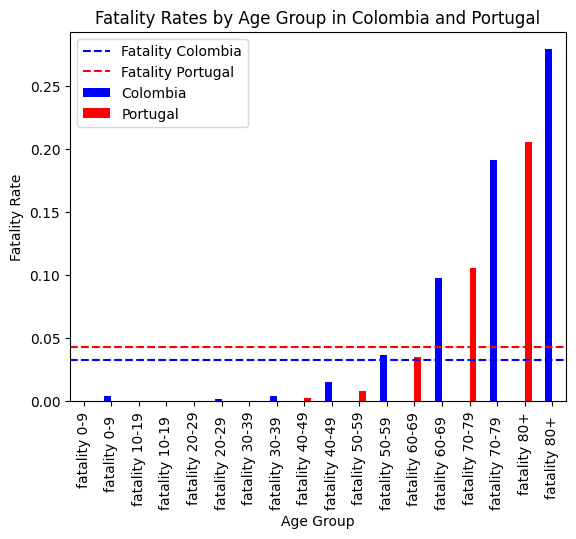

In [20]:
## YOUR CODE HERE
# I create this code with help of an AI-tool.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



df = pd.DataFrame({'Colombia': fatality_rates_CO, 'Portugal': fatality_rates_PT})
df.plot(kind='bar', color=['b', 'r'])

plt.axhline(y=fatal_CO, color='b', linestyle='--', label='Fatality Colombia')
plt.axhline(y=fatal_PT, color='r', linestyle='--', label='Fatality Portugal')


plt.title('Fatality Rates by Age Group in Colombia and Portugal')
plt.xlabel('Age Group')
plt.ylabel('Fatality Rate')
plt.legend()

# Show the plot
plt.show()


***BONUS (1pt): Do you notice anything strange? Can you explain what is going on?***

OPTIONAL: YOUR ANSWER HERE

 By the age groups 20-29 and 30-39 of Portugal is no bar, but there is fatality rate > 0.
 I think that you can not see the bars, because the numbers of the fatality rate is not high enought to get a bar for this numbers.
 The numbers of the fatality rate of Colombia is high enought to get a bar for the numbers.